# GDELT Test: Reuters Energy Headlines

This notebook demonstrates how to use GDELT (Global Database of Events, Language, and Tone) to fetch recent Reuters headlines about energy topics.

TEst


In [40]:
# Import required libraries
import requests
import pandas as pd
import json
from datetime import datetime, timedelta
import time
import re


In [41]:
def fetch_energy_news(max_records=50):
    """
    Fetch energy-related news headlines from specific sources
    
    Parameters:
    - max_records: Maximum number of records to fetch (default: 50)
    
    Returns:
    - DataFrame with news headlines
    """
    
    # GDELT API endpoint
    base_url = "https://api.gdeltproject.org/api/v2/doc/doc"
    
    # Query parameters for energy topics from all English sources
    energy_query = "(energy OR oil OR \"natural gas\" OR coal OR petroleum OR crude OR renewable OR solar OR wind OR nuclear OR electricity OR power OR fuel)"
    
    params = {
        'query': f'{energy_query} sourcelang:english',
        'mode': 'artlist',
        'maxrecords': max_records,
        'format': 'json'
    }
    
    print(f"Fetching {max_records} energy-related headlines from all English sources...")
    
    try:
        # Make API request
        response = requests.get(base_url, params=params, timeout=30)
        response.raise_for_status()
        
        # Parse JSON response
        data = response.json()
        
        if 'articles' in data and data['articles']:
            articles = data['articles']
            print(f"Successfully fetched {len(articles)} articles")
            
            # Convert to DataFrame
            df = pd.DataFrame(articles)
            
            # Show what columns we got
            print(f"Available columns: {list(df.columns)}")
            
            # Keep only basic columns that are likely to exist
            basic_columns = []
            if 'title' in df.columns:
                basic_columns.append('title')
            if 'url' in df.columns:
                basic_columns.append('url')
            if 'seendate' in df.columns:
                basic_columns.append('seendate')
            if 'domain' in df.columns:
                basic_columns.append('domain')
            
            if basic_columns:
                df = df[basic_columns]
                # Rename title to headline for consistency
                if 'title' in df.columns:
                    df = df.rename(columns={'title': 'headline'})
                if 'seendate' in df.columns:
                    df = df.rename(columns={'seendate': 'date'})
            
            return df
        else:
            print("No articles found in response")
            return pd.DataFrame()
            
    except requests.exceptions.RequestException as e:
        print(f"Error fetching data: {e}")
        return pd.DataFrame()
    except json.JSONDecodeError as e:
        print(f"Error parsing JSON response: {e}")
        return pd.DataFrame()
    except Exception as e:
        print(f"Unexpected error: {e}")
        return pd.DataFrame()


In [ ]:
# Fetch 50 energy-related headlines from specific sources
headlines = fetch_energy_news(max_records=200)

# Display basic information about the fetched data
print(f"\nFetched {len(headlines)} energy-related headlines from all English sources")

# Show the data
if not headlines.empty:
    print(f"Available columns: {list(headlines.columns)}")
    
    # Show first 10 headlines
    print("\nFirst 10 headlines:")
    for i, row in headlines.head(10).iterrows():
        print(f"{i+1}. {row.get('headline', 'No headline')}")
        if 'date' in headlines.columns:
            print(f"   Date: {row.get('date', 'No date')}")
        if 'url' in headlines.columns:
            print(f"   URL: {row.get('url', 'No URL')}")
        if 'domain' in headlines.columns:
            print(f"   Domain: {row.get('domain', 'No domain')}")
        print()
else:
    print("No headlines were fetched. The GDELT API might be having issues or the query returned no results.")


Fetching 50 energy-related headlines from all English sources...
Successfully fetched 50 articles
Available columns: ['url', 'url_mobile', 'title', 'seendate', 'socialimage', 'domain', 'language', 'sourcecountry']

Fetched 50 energy-related headlines from all English sources
Available columns: ['headline', 'url', 'date', 'domain']

First 10 headlines:
1. Electricity Generated From Wind and Solar Cannot Replace Fossil Fuels ! 
   Date: 20250802T033000Z
   URL: https://newswithviews.com/electricity-generated-from-wind-and-solar-cannot-replace-fossil-fuels/
   Domain: newswithviews.com

2. Fossil Fuels Keep The Lights On While Wind And Solar Fall Short
   Date: 20250730T221500Z
   URL: https://climatechangedispatch.com/fossil-fuels-vs-renewables/
   Domain: climatechangedispatch.com

3. Electricity generated from wind and solar cannot replace fossil fuels ! - On Line Opinion
   Date: 20250730T023000Z
   URL: https://www.onlineopinion.com.au/view.asp?article=23581
   Domain: onlineopinion.

In [43]:
# Display the DataFrame structure and basic statistics
if not headlines.empty:
    print("DataFrame Info:")
    print(headlines.info())
    print("\nDataFrame Shape:", headlines.shape)
    print("\nColumn Names:", list(headlines.columns))
    
    # Show sample of the data
    print("\nSample of the data:")
    print(headlines.head())
    
    # Check for any missing values
    print("\nMissing values per column:")
    print(headlines.isnull().sum())
    
    # Show data types
    print("\nData types:")
    print(headlines.dtypes)
else:
    print("No data to display.")


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   headline  50 non-null     object
 1   url       50 non-null     object
 2   date      50 non-null     object
 3   domain    50 non-null     object
dtypes: object(4)
memory usage: 1.7+ KB
None

DataFrame Shape: (50, 4)

Column Names: ['headline', 'url', 'date', 'domain']

Sample of the data:
                                            headline  \
0  Electricity Generated From Wind and Solar Cann...   
1  Fossil Fuels Keep The Lights On While Wind And...   
2  Electricity generated from wind and solar cann...   
3  U . S . sets record for exporting energy , mos...   
4  Renewables and coal are working to push out cr...   

                                                 url              date  \
0  https://newswithviews.com/electricity-generate...  20250802T033000Z   
1  https://climatechange

In [44]:
# Save the data to CSV for further analysis
if not headlines.empty:
    output_file = "/Users/nicolas/Desktop/Repos/zhaw_arep/data/raw/gdelt_energy_headlines.csv"
    headlines.to_csv(output_file, index=False)
    print(f"Data saved to: {output_file}")
    
    # Also save as a pickle file for faster loading
    pickle_file = "/Users/nicolas/Desktop/Repos/zhaw_arep/data/processed/gdelt_energy_headlines.pkl"
    headlines.to_pickle(pickle_file)
    print(f"Data also saved as pickle to: {pickle_file}")
else:
    print("No data to save.")


Data saved to: /Users/nicolas/Desktop/Repos/zhaw_arep/data/raw/gdelt_energy_headlines.csv
Data also saved as pickle to: /Users/nicolas/Desktop/Repos/zhaw_arep/data/processed/gdelt_energy_headlines.pkl


In [45]:
def fetch_simple_news_fallback(max_records=50):
    """
    Fallback function to fetch energy news without source restrictions
    """
    base_url = "https://api.gdeltproject.org/api/v2/doc/doc"
    
    # Broader energy query without source restrictions
    params = {
        'query': '(energy OR oil OR "natural gas" OR coal) sourcelang:english',
        'mode': 'artlist',
        'maxrecords': max_records,
        'format': 'json'
    }
    
    print(f"Fetching {max_records} energy headlines from all English sources...")
    
    try:
        response = requests.get(base_url, params=params, timeout=30)
        response.raise_for_status()
        data = response.json()
        
        if 'articles' in data and data['articles']:
            articles = data['articles']
            print(f"Successfully fetched {len(articles)} articles")
            df = pd.DataFrame(articles)
            
            # Show what columns we got
            print(f"Available columns: {list(df.columns)}")
            
            # Keep only basic columns that are likely to exist
            basic_columns = []
            if 'title' in df.columns:
                basic_columns.append('title')
            if 'url' in df.columns:
                basic_columns.append('url')
            if 'seendate' in df.columns:
                basic_columns.append('seendate')
            if 'domain' in df.columns:
                basic_columns.append('domain')
            
            if basic_columns:
                df = df[basic_columns]
                if 'title' in df.columns:
                    df = df.rename(columns={'title': 'headline'})
                if 'seendate' in df.columns:
                    df = df.rename(columns={'seendate': 'date'})
            
            return df
        else:
            print("No articles found in response")
            return pd.DataFrame()
            
    except Exception as e:
        print(f"Error in fallback query: {e}")
        return pd.DataFrame()

# Try alternative energy queries if the first one didn't work
if headlines.empty:
    print("Trying alternative energy queries...")
    
    # Try a broader energy query without source restrictions
    print("\nTrying broader energy query without source restrictions...")
    headlines = fetch_simple_news_fallback(max_records=50)
    
    if not headlines.empty:
        print(f"\nSuccess! Fetched {len(headlines)} headlines")
        print("First 5 headlines:")
        for i, row in headlines.head(5).iterrows():
            print(f"{i+1}. {row.get('headline', 'No headline')}")
    else:
        print("All queries failed. The GDELT API might be down or having issues.")


In [46]:
# Install required packages for wordcloud (run this cell first if needed)
# !pip install wordcloud matplotlib

import matplotlib.pyplot as plt
from wordcloud import WordCloud
import re
from collections import Counter


In [47]:
def create_wordcloud_analysis(df, title="Word Cloud Analysis"):
    """
    Create a word cloud from headlines
    
    Parameters:
    - df: DataFrame with headlines
    - title: Title for the plot
    """
    
    if df.empty or 'headline' not in df.columns:
        print("No headlines available for word cloud analysis")
        return
    
    # Combine all headlines into one text
    all_headlines = ' '.join(df['headline'].dropna().astype(str))
    
    if not all_headlines.strip():
        print("No valid headlines found for word cloud analysis")
        return
    
    # Clean the text - remove special characters and convert to lowercase
    cleaned_text = re.sub(r'[^a-zA-Z\s]', '', all_headlines.lower())
    
    # Remove common stop words
    stop_words = {'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for', 'of', 'with', 'by', 'is', 'are', 'was', 'were', 'be', 'been', 'have', 'has', 'had', 'do', 'does', 'did', 'will', 'would', 'could', 'should', 'may', 'might', 'can', 'this', 'that', 'these', 'those', 'i', 'you', 'he', 'she', 'it', 'we', 'they', 'me', 'him', 'her', 'us', 'them', 'my', 'your', 'his', 'her', 'its', 'our', 'their', 'from', 'up', 'down', 'out', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than', 'too', 'very', 'just', 'now'}
    
    # Filter out stop words and short words
    words = [word for word in cleaned_text.split() if word not in stop_words and len(word) > 2]
    
    if not words:
        print("No meaningful words found after filtering")
        return
    
    # Create word cloud
    wordcloud = WordCloud(
        width=800, 
        height=400, 
        background_color='white',
        max_words=100,
        colormap='viridis',
        relative_scaling=0.5,
        random_state=42
    ).generate(' '.join(words))
    
    # Create the plot
    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()
    
    # Show most common words
    word_counts = Counter(words)
    print(f"\nTop 20 most common words:")
    for word, count in word_counts.most_common(20):
        print(f"{word}: {count}")
    
    return word_counts


Creating word cloud analysis...


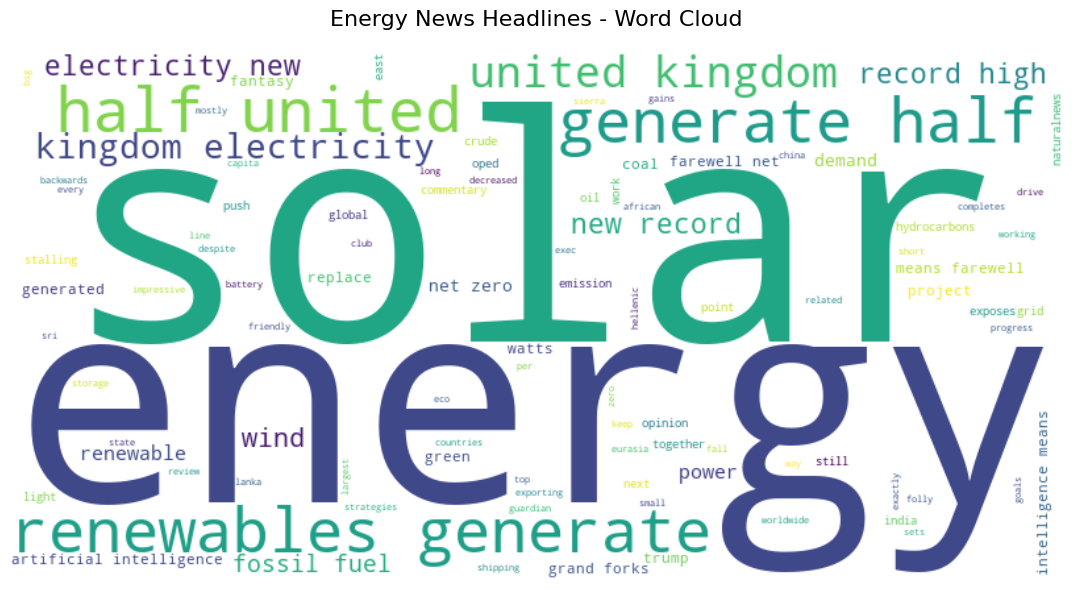


Top 20 most common words:
electricity: 18
solar: 14
energy: 13
record: 12
renewables: 12
generate: 12
half: 11
united: 11
kingdom: 11
new: 11
high: 11
wind: 10
fossil: 8
fuels: 7
zero: 5
power: 5
demand: 4
net: 4
renewable: 4
generated: 3

Total headlines analyzed: 50
Total unique words: 203
Total word count: 418

Source breakdown:
newswithviews.com: 3 articles
wattsupwiththat.com: 3 articles
washingtonexaminer.com: 2 articles
eurasiareview.com: 2 articles
naturalnews.com: 2 articles
power-technology.com: 2 articles
oilprice.com: 2 articles
keighleynews.co.uk: 1 articles
newsandstar.co.uk: 1 articles
wiltshiretimes.co.uk: 1 articles
northwaleschronicle.co.uk: 1 articles
somersetcountygazette.co.uk: 1 articles
harrowtimes.co.uk: 1 articles
northwichguardian.co.uk: 1 articles
thehindubusinessline.com: 1 articles
reviewjournal.com: 1 articles
thurrockgazette.co.uk: 1 articles
finance.yahoo.com: 1 articles
grandforksherald.com: 1 articles
courant.com: 1 articles
dailypolitical.com: 1 arti

In [48]:
# Create word cloud analysis
if not headlines.empty:
    print("Creating word cloud analysis...")
    word_counts = create_wordcloud_analysis(headlines, "Energy News Headlines - Word Cloud")
    
    # Additional analysis
    print(f"\nTotal headlines analyzed: {len(headlines)}")
    print(f"Total unique words: {len(word_counts)}")
    print(f"Total word count: {sum(word_counts.values())}")
    
    # Show source breakdown if available
    if 'domain' in headlines.columns:
        print(f"\nSource breakdown:")
        source_counts = headlines['domain'].value_counts()
        for source, count in source_counts.items():
            print(f"{source}: {count} articles")
else:
    print("No headlines available for word cloud analysis")


In [ ]:
# Plot domain origins count
if not headlines.empty and 'domain' in headlines.columns:
    print("Creating domain origins plot...")
    
    # Count domains
    domain_counts = headlines['domain'].value_counts()
    
    # Create the plot
    plt.figure(figsize=(12, 8))
    domain_counts.plot(kind='bar', color='steelblue', alpha=0.7)
    plt.title('News Headlines by Domain Origin', fontsize=16, pad=20)
    plt.xlabel('Domain', fontsize=12)
    plt.ylabel('Number of Headlines', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Print domain statistics
    print(f"\nDomain Statistics:")
    print(f"Total unique domains: {len(domain_counts)}")
    print(f"Total headlines: {len(headlines)}")
    print(f"\nTop 10 domains:")
    for i, (domain, count) in enumerate(domain_counts.head(10).items(), 1):
        print(f"{i:2d}. {domain}: {count} headlines")
        
    # Calculate diversity metrics
    total_headlines = len(headlines)
    unique_domains = len(domain_counts)
    most_common_domain_count = domain_counts.iloc[0] if len(domain_counts) > 0 else 0
    concentration_ratio = most_common_domain_count / total_headlines if total_headlines > 0 else 0
    
    print(f"\nDiversity Metrics:")
    print(f"Concentration ratio (top domain): {concentration_ratio:.2%}")
    print(f"Average headlines per domain: {total_headlines/unique_domains:.1f}")
    
else:
    print("No domain information available for plotting.")


## Alternative Approach: Using GDELT's BigQuery Interface

If the API approach doesn't work well, here's an alternative method using GDELT's BigQuery interface (requires Google Cloud setup):


In [49]:
# Alternative BigQuery approach (commented out - requires Google Cloud setup)
"""
from google.cloud import bigquery
import os

def fetch_gdelt_bigquery(query, max_records=100):
    # Set up BigQuery client
    client = bigquery.Client()
    
    # SQL query for GDELT data
    query_sql = f'''
    SELECT 
        title,
        url,
        datetime,
        sourceurl,
        domain
    FROM `gdelt-bq.gdeltv2.gkg`
    WHERE 
        V2Themes LIKE '%{query}%'
        AND V2SourceCommonName = 'REUTERS'
        AND V2DocumentIdentifier IS NOT NULL
    ORDER BY datetime DESC
    LIMIT {max_records}
    '''
    
    # Execute query
    query_job = client.query(query_sql)
    results = query_job.result()
    
    # Convert to DataFrame
    df = pd.DataFrame([dict(row) for row in results])
    
    return df

# Uncomment to use BigQuery approach
# energy_headlines_bq = fetch_gdelt_bigquery("energy", 100)
"""

print("BigQuery approach is available but commented out.")
print("To use it, you'll need to:")
print("1. Set up Google Cloud credentials")
print("2. Install google-cloud-bigquery: pip install google-cloud-bigquery")
print("3. Uncomment the code above")


BigQuery approach is available but commented out.
To use it, you'll need to:
1. Set up Google Cloud credentials
2. Install google-cloud-bigquery: pip install google-cloud-bigquery
3. Uncomment the code above
